# Nonlinear Regression with ParmEst, Including Regularization

In [3]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load and explore experimental data

In [4]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


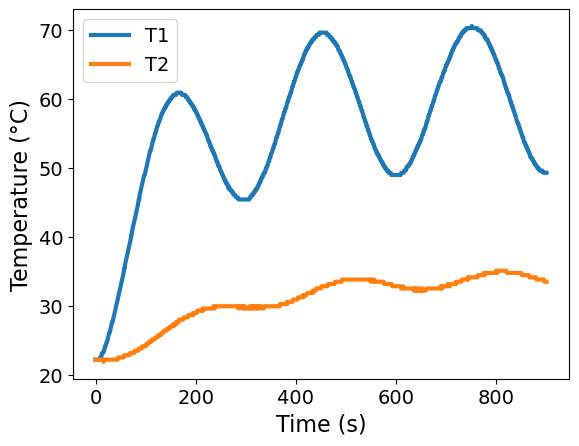

In [5]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

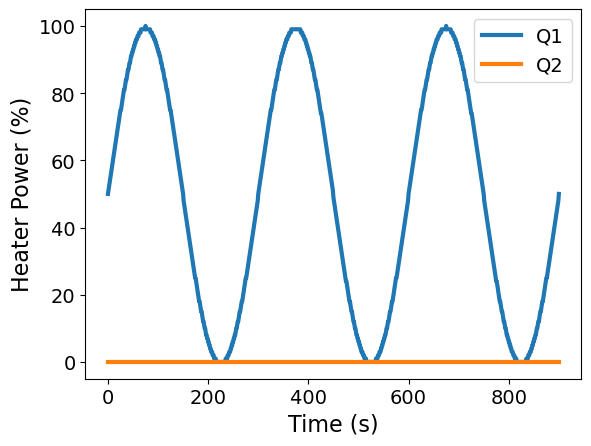

In [6]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

## Store in Custom Data Class 

In the file `tclab_pyomo.py`, we defined a `dataclass` for convenience. It is essentially a light weight container to store experimental data.

In [7]:
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values,
    T1=df['T1'].values,
    u1=df['Q1'].values,
    P1=200,
    TS1_data=None,
    T2=df['T2'].values,
    u2=df['Q2'].values,
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

In [8]:
tc_data.to_data_frame().head()

,time,T1,u1,P1,TS1_data,T2,u2,P2,TS2_data,Tamb
0,0.00,22.2,50,200,None,22.2,0,200,None,22.2
1,1.01,22.2,51,200,None,22.2,0,200,None,22.2
2,2.01,22.2,52,200,None,22.2,0,200,None,22.2
3,3.00,22.2,53,200,None,22.2,0,200,None,22.2
4,4.01,22.2,54,200,None,22.2,0,200,None,22.2


## Parameter Estimation with ParmEst

We seek to solve minimize the sum of residuals squared:

$$
\begin{align*}
\min_{C_p^H, C_p^S, U_a, U_b} \sum_{i \in \mathcal{T}} \left(T_{S}(t_i) - \bar{T}_{S,i} \right)^2
\end{align*}
$$

subject to constraints

$$
\begin{align*}
C_p^H \frac{dT_H}{dt} & = U_a (T_{amb} - T_H) + U_c (T_S - T_H) + \alpha P u(t)\\
C_p^S \frac{dT_S}{dt} & = - U_b (T_S - T_H)  \\
\\
\text{control input data}\qquad u(t_i) & = \bar{u}_{i}, \forall i \in \mathcal{T}
\\
\text{initial condition}\qquad T_H(t_0) & = T_{amb} \\
\text{initial condition}\qquad T_S(t_0) & = T_{amb}
\end{align*}
$$

Here $\bar{T}_{S,i}$ and $\bar{u}_i$ are the measured sensor temperatures and control signals, respectives, at times $i \in \mathcal{T}$. $w$ is a small weight that helps regularize the solution by preventing the model predictions $T_H$ from deviating too much from the measured temperatures.


In the `tclab_pyomo.py` model, we defined several helper functions:
* `extract_results` takes a Pyomo model and returns the results stored in an instance of the `TC_Lab_data` dataclass.
* `extract_plot_results` takes experimental data (stored in a `TC_Lab_data` instance) and a Pyomo model. The function then generates plots showing the data and model predictions.
* `results_summary` summarizes the Pyomo.DoE results. We'll use this later in the workshop.

`parmest` has been refactored to allow users to directly ask for the sum of squared error (SSE) objective. Custom objectives can also be provided, but are outside the scope of this workshop.

In [9]:
import pyomo.contrib.parmest.parmest as parmest

# First, we define an Experiment object within parmest
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states)

solver_options = {
                  'linear_solver': 'ma57', 
                  'max_iter': 100
                  }
# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', tee=True, solver_options=solver_options)

obj, theta = pest.theta_est()

Ipopt 3.13.2: linear_solver=ma57
max_iter=100


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific


## Added sections - Stephen

### Calculate covariance

In [10]:
# Use cov_est to calculate the covariance of the parameter estimates. This is a useful metric for understanding the uncertainty in the parameter estimates, and can be used to construct confidence intervals or perform hypothesis testing on the parameters.
cov = pest.cov_est()
print("Covariance of parameter estimates:\n", cov)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [11]:
import numpy as np
# Do eigendecomposition of covariance matrix to find principal directions of uncertainty
eigenvalues, eigenvectors = np.linalg.eig(cov)
print("\nEigenvalues of covariance matrix:\n", eigenvalues)
print("\nEigenvectors of covariance matrix:\n", eigenvectors)


Eigenvalues of covariance matrix:
 [0.00000000e+00 2.29261748e+10 4.92987646e-08 1.71171922e-09]

Eigenvectors of covariance matrix:
 [[-1.00000000e+00 -9.32318552e-11 -3.08324652e-02 -3.44150175e-02]
 [ 4.75145066e-13 -5.09638111e-03  2.38940516e-01  9.77959480e-01]
 [ 3.18163868e-13 -3.41260899e-03 -9.70542324e-01  2.05860446e-01]
 [-9.32301016e-11  9.99981190e-01 -2.09438893e-03  5.68668239e-03]]


### Try regularization

In [12]:

# Use the inverse of the covariance matrix as the prior_FIM, and try regularization with the 
# step test data

prior_FIM = pd.DataFrame(np.linalg.inv(cov), index=cov.index, columns=cov.columns)
print("\nPrior FIM from inverse of covariance matrix:\n", prior_FIM)

# Check psd and symmetry of the prior FIM
if np.allclose(prior_FIM, prior_FIM.T):
    print("\nPrior FIM is symmetric.")
else:
    print("\nPrior FIM is not symmetric.")
    print("Prior FIM:\n", prior_FIM)

if np.all(np.linalg.eigvals(prior_FIM) >= 0):
    print("\nPrior FIM is positive semi-definite.")
else:
    print("\nPrior FIM is not positive semi-definite.")
    print("Eigenvalues:\n", np.linalg.eigvals(prior_FIM))

prior_FIM_sym = prior_FIM + prior_FIM.T - np.diag(prior_FIM.values.diagonal())
print("\nSymmetrized Prior FIM:\n", prior_FIM_sym)

# Check it is symmetric
if np.allclose(prior_FIM_sym, prior_FIM_sym.T):
    print("\nPrior FIM is symmetric.")
else:
    print("\nPrior FIM is not symmetric.")

# Check it is positive semi-definite
eigenvalues = np.linalg.eigvals(prior_FIM_sym)
if np.all(eigenvalues >= 0):
    print("\nPrior FIM is positive semi-definite.")
else:
    print("\nPrior FIM is not positive semi-definite.")
    print("Eigenvalues:\n", eigenvalues)

theta0 = theta
print("\nInitial parameter values for regularized estimation:\n", theta0)


Prior FIM from inverse of covariance matrix:
                    Ua            Ub       inv_CpH       inv_CpS
Ua       7.184143e+09  6.193367e+07 -2.110813e+08 -4.047075e+05
Ub       6.614480e+07  4.454044e+08  1.036300e+08  2.623648e+06
inv_CpH -2.099084e+08  1.041507e+08  5.262386e+07  7.103895e+05
inv_CpS -3.792425e+05  2.625425e+06  7.077359e+05  1.579569e+04

Prior FIM is not symmetric.
Prior FIM:
                    Ua            Ub       inv_CpH       inv_CpS
Ua       7.184143e+09  6.193367e+07 -2.110813e+08 -4.047075e+05
Ub       6.614480e+07  4.454044e+08  1.036300e+08  2.623648e+06
inv_CpH -2.099084e+08  1.041507e+08  5.262386e+07  7.103895e+05
inv_CpS -3.792425e+05  2.625425e+06  7.077359e+05  1.579569e+04

Prior FIM is positive semi-definite.

Symmetrized Prior FIM:
                    Ua            Ub       inv_CpH       inv_CpS
Ua       7.184143e+09  1.280785e+08 -4.209897e+08 -7.839500e+05
Ub       1.280785e+08  4.454044e+08  2.077807e+08  5.249074e+06
inv_CpH -4.209897

In [13]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# # Copied from previous notebook
# theta_values = {
#     'Ua': 0.0417051733576387,
#     'Ub': 0.009440714239773074,
#     'inv_CpH': 0.1659093525658045,
#     'inv_CpS': 5.8357556063605465,
# }

In [14]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta, number_of_states=number_tclab_states)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=True, 
                                 tee=True,)

FIM = TC_Lab_DoE.compute_FIM(method='sequential')

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [15]:
results_summary(FIM)


======Results Summary======
Four design criteria log10() value:
A-optimality: 7.156011892800069
D-optimality: 12.026397735992937
E-optimality: -6.253856176661979
Modified E-optimality: 13.357551614686411

FIM:
 [[12494781.15705735    45488.17139878 -1498233.66627409   -51360.82705048]
 [   45488.17139878   130722.5486305    305255.1502064    141672.00178262]
 [-1498233.66627409   305255.1502064   1539972.79397751   382720.78844664]
 [  -51360.82705048   141672.00178262   382720.78844664   156794.69141182]]

eigenvalues:
 [1.26968201e+07 1.52712588e+06 9.83252294e+04 5.57370300e-07]

eigenvectors:
 [[ 9.91034839e-01  1.26443331e-01 -4.31512616e-02 -5.11393830e-07]
 [ 2.56362804e-04  2.34068605e-01  6.91771849e-01 -6.83127756e-01]
 [-1.33356092e-01  9.23214862e-01 -3.57490063e-01 -4.57310275e-02]
 [-8.12615565e-03  2.77305411e-01  6.25931732e-01  7.28865654e-01]]


In [16]:
print(FIM)


prior_FIM_doe = pd.DataFrame(FIM, index=theta.index, columns=theta.index)
print("\nPrior FIM from DoE:\n", prior_FIM_doe)

[[12494781.15705735    45488.17139878 -1498233.66627409   -51360.82705048]
 [   45488.17139878   130722.5486305    305255.1502064    141672.00178262]
 [-1498233.66627409   305255.1502064   1539972.79397751   382720.78844664]
 [  -51360.82705048   141672.00178262   382720.78844664   156794.69141182]]

Prior FIM from DoE:
                    Ua             Ub       inv_CpH        inv_CpS
Ua       1.249478e+07   45488.171399 -1.498234e+06  -51360.827050
Ub       4.548817e+04  130722.548631  3.052552e+05  141672.001783
inv_CpH -1.498234e+06  305255.150206  1.539973e+06  382720.788447
inv_CpS -5.136083e+04  141672.001783  3.827208e+05  156794.691412


## Load and explore experimental data (step test)

In [17]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_step_test.csv"
else:
    file = '../data/tclab_step_test.csv'
df_step = pd.read_csv(file)
df_step.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.84,22.84,50.0,0.0
1,1.00,22.84,22.84,50.0,0.0
2,2.01,23.16,22.84,50.0,0.0
3,3.02,22.84,22.84,50.0,0.0
4,4.01,22.84,22.84,50.0,0.0


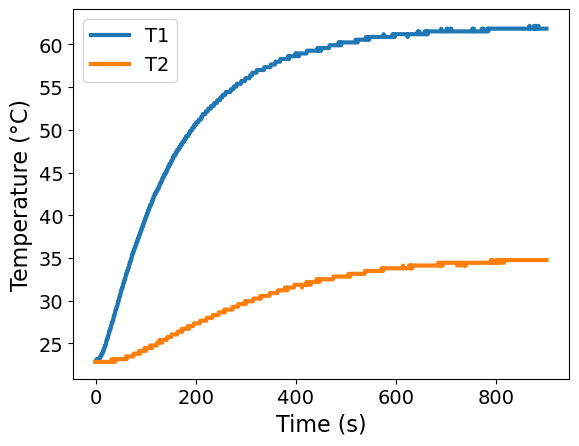

In [18]:
ax = df_step.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

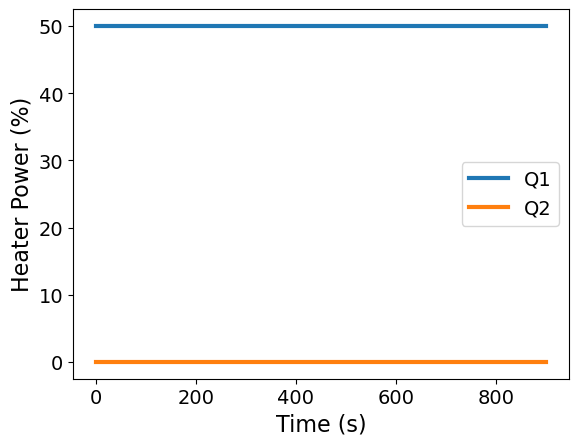

In [19]:
ax = df_step.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

In [20]:
def df_to_dataclass(df):
    tc_data = TC_Lab_data(
        name="Sine Wave Test for Heater 1",
        time=df['Time'].values,
        T1=df['T1'].values,
        u1=df['Q1'].values,
        P1=200,
        TS1_data=None,
        T2=df['T2'].values,
        u2=df['Q2'].values,
        P2=200,
        TS2_data=None,
        Tamb=df['T1'].values[0],
    )
    return tc_data

tc_data_step = df_to_dataclass(df_step)

In [21]:
TC_Lab_step_exp = TC_Lab_experiment(data=tc_data_step, number_of_states=number_tclab_states)

solver_options = {
                  'linear_solver': 'ma57', 
                  'max_iter': 100
                  }
# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest_data_L2 = parmest.Estimator([TC_Lab_step_exp, ], obj_function='SSE', tee=True, solver_options=solver_options, regularization='L2', prior_FIM=prior_FIM_doe, theta_ref=theta0)

obj, theta = pest_data_L2.theta_est()




Ipopt 3.13.2: linear_solver=ma57
max_iter=100


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific


In [22]:
# Repeat with L1 regularization

solver_options = {
                  'linear_solver': 'ma57', 
                  'max_iter': 100
                  }
# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest_data_L1 = parmest.Estimator([TC_Lab_step_exp, ], obj_function='SSE', tee=True, solver_options=solver_options, regularization='L1', prior_FIM=prior_FIM_doe, theta_ref=theta0)

obj, theta = pest_data_L1.theta_est()

Ipopt 3.13.2: linear_solver=ma57
max_iter=100


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific


In [23]:
# Calculate covariance of parameter estimates for regularized estimation
cov_regL2 = pest_data_L2.cov_est(method='reduced_hessian')
print("\nCovariance of parameter estimates with L2 regularization:\n", cov_regL2)



Ipopt 3.13.2: linear_solver=ma57
max_iter=100
bound_relax_factor=0
honor_original_bounds=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collectio

In [24]:
cov_regL1 = pest_data_L1.cov_est(method='reduced_hessian')
print("\nCovariance of parameter estimates with L1 regularization:\n", cov_regL1)

Ipopt 3.13.2: linear_solver=ma57
max_iter=100
bound_relax_factor=0
honor_original_bounds=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collectio

In [25]:
# Repeat with L1 regularization using physically informed prior

import numpy as np
import pandas as pd

# ---- Physically intuitive guesses (Cp-space) ----
theta_phys = pd.Series({
    "Ua": 0.030,   # W/K, ambient loss from heater node
    "Ub": 0.018,   # W/K, heater-to-sensor coupling
    "CpH": 7.5,    # J/K, heater thermal mass
    "CpS": 0.22,   # J/K, sensor thermal mass
})

# 1-sigma uncertainty
sigma_phys = pd.Series({
    "Ua": 0.012,
    "Ub": 0.005,
    "CpH": 1.5,
    "CpS": 0.12,
})

# Correlation structure from physical/non-identifiability intuition
corr_phys = pd.DataFrame(
    [[ 1.00, -0.20,  0.55, 0.05],
    [-0.20,  1.00,  0.25, 0.75],
    [ 0.55,  0.25,  1.00, 0.30],
    [ 0.05,  0.75,  0.30, 1.00]
    ],
    index=["Ua","Ub","CpH","CpS"],
    columns=["Ua","Ub","CpH","CpS"],
)

# Covariance in physical parameter space
D = np.diag(sigma_phys.values)
cov_phys = pd.DataFrame(D @ corr_phys.values @ D, index=corr_phys.index, columns=corr_phys.columns)

# Transform to estimator parameterization [Ua, Ub, inv_CpH, inv_CpS]
theta0_phys = pd.Series({
    "Ua": theta_phys["Ua"],
    "Ub": theta_phys["Ub"],
    "inv_CpH": 1.0 / theta_phys["CpH"],
    "inv_CpS": 1.0 / theta_phys["CpS"],
})

J = np.diag([
    1.0,
    1.0,
    -1.0 / theta_phys["CpH"]**2,
    -1.0 / theta_phys["CpS"]**2,
])

cov_x = pd.DataFrame(
    J @ cov_phys.values @ J.T,
    index=["Ua","Ub","inv_CpH","inv_CpS"],
    columns=["Ua","Ub","inv_CpH","inv_CpS"],
)

prior_FIM_phys = pd.DataFrame(
    np.linalg.inv(cov_x.values),
    index=cov_x.index,
    columns=cov_x.columns,
)

# Optional scaling factor to tune regularization strength
prior_weight = 0.05
prior_FIM_phys = prior_weight * prior_FIM_phys

print("theta0_phys:", theta0_phys)
print("prior_FIM_phys:\n", prior_FIM_phys)

solver_options = {
                  'linear_solver': 'ma57',
                  'max_iter': 100
                  }

# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest_regL1_phys = parmest.Estimator([TC_Lab_step_exp, ], obj_function='SSE', tee=True, solver_options=solver_options, regularization='L1', prior_FIM=prior_FIM_phys, theta_ref=theta0_phys)

obj_phys, theta_phys_est = pest_regL1_phys.theta_est()

print("\nL1 (physical prior) objective:", obj_phys)
print("L1 (physical prior) theta:\n", theta_phys_est)


theta0_phys: Ua         0.030000
Ub         0.018000
inv_CpH    0.133333
inv_CpS    4.545455
dtype: float64
prior_FIM_phys:
                  Ua           Ub     inv_CpH   inv_CpS
Ua       646.164950   895.365169  175.561798  0.944132
Ub       895.365169  5819.288390  266.853933  8.157303
inv_CpH  175.561798   266.853933  125.087781  0.042486
inv_CpS    0.944132     8.157303    0.042486  0.020563
Ipopt 3.13.2: linear_solver=ma57
max_iter=100


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright

In [26]:
# Calculate covariance of parameter estimates for regularized estimation with physical prior
cov_regL1_phys = pest_regL1_phys.cov_est(method='reduced_hessian')
print("\nCovariance of parameter estimates with L1 regularization and physical prior:\n", cov_regL1_phys)  

Ipopt 3.13.2: linear_solver=ma57
max_iter=100
bound_relax_factor=0
honor_original_bounds=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collectio

In [ ]:
FIM = np.linalg.inv(cov_regL1_phys)
# Check symmetry
if np.allclose(FIM, FIM.T):
    print("\nFIM is symmetric.")
else:
    print("\nFIM is not symmetric.")
    print("FIM:\n", FIM)

    # 1/2 cov + 1/2 cov.T to symmetrize


FIM is symmetric.


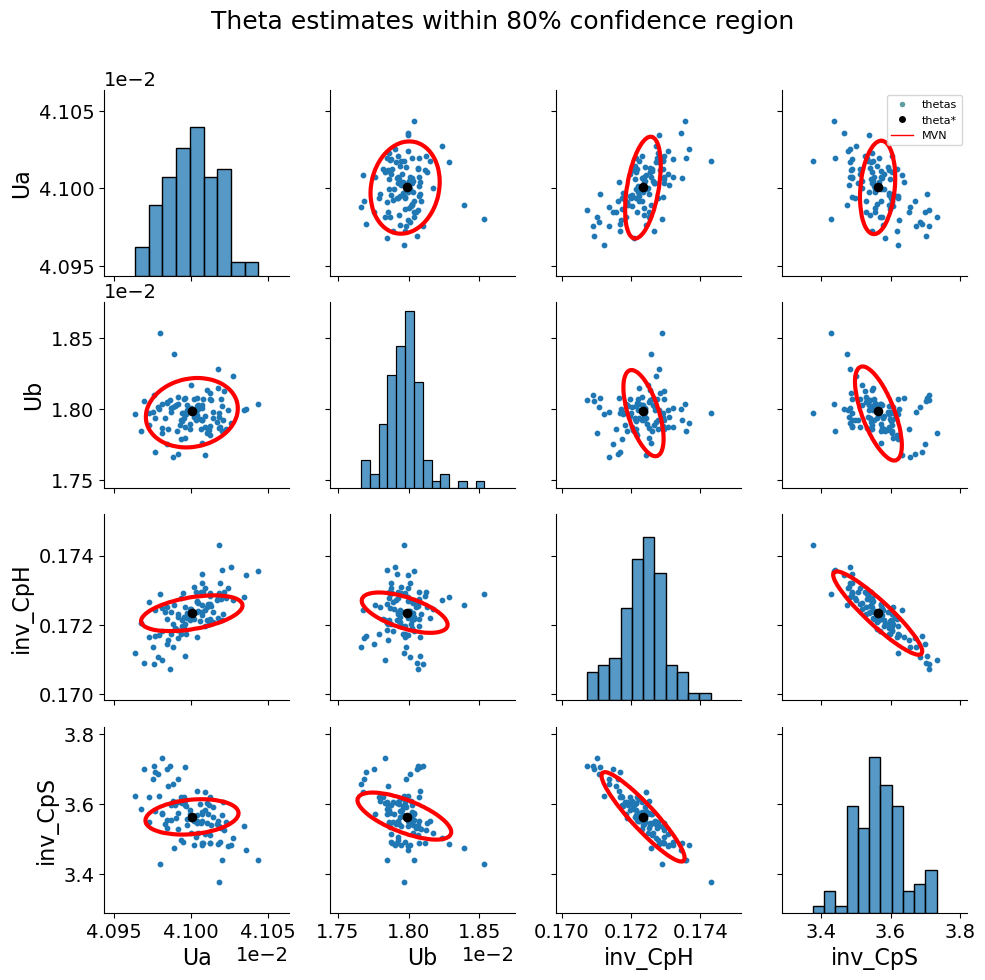

In [25]:
if parmest.graphics.seaborn_available:
    parmest.graphics.pairwise_plot(
        (theta_phys_est, cov_regL1_phys, 100),
        theta_star=theta_phys_est,
        alpha=0.8,
        distributions=['MVN'],
        title='Theta estimates within 80% confidence region',
    )

Ipopt 3.13.2: linear_solver=ma57
max_iter=100


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific


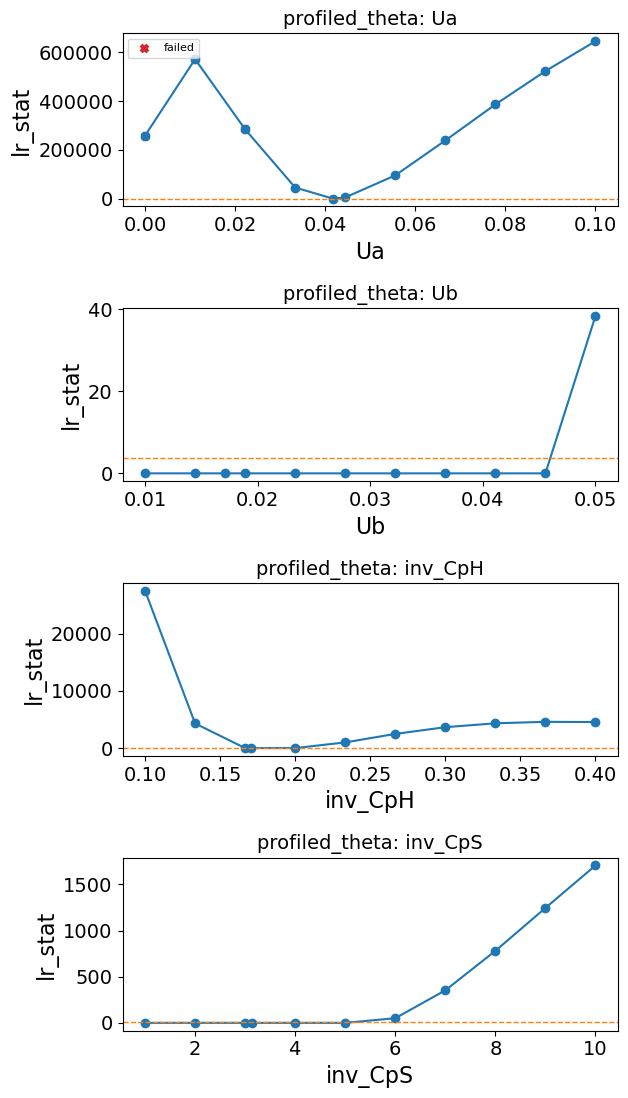

In [26]:
# Profile likelihood for each parameter with no prior
profile_results_no_prior = pest.profile_likelihood(
    profiled_theta=["Ua", "Ub", "inv_CpH", "inv_CpS"],
    n_grid=10,
    solver="ef_ipopt",
    warmstart="neighbor",
    )
# Profile likelihood for each parameter with L1 regularization and physical prior
# Display a compact summary table
profiles = profile_results_no_prior["profiles"]
print("\nBaseline:")
print(profile_results_no_prior["baseline"])
print("\nProfile results (first 12 rows):")
print(
    profiles[
        [
            "profiled_theta",
            "theta_value",
            "obj",
            "delta_obj",
            "lr_stat",
            "status",
            "success",
        ]
    ].head(12)
)

# Plot profile curves to file for terminal/non-GUI usage
parmest.graphics.profile_likelihood_plot(
    profile_results_no_prior, alpha=0.95, 
)


Ipopt 3.13.2: linear_solver=ma57
max_iter=100


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific


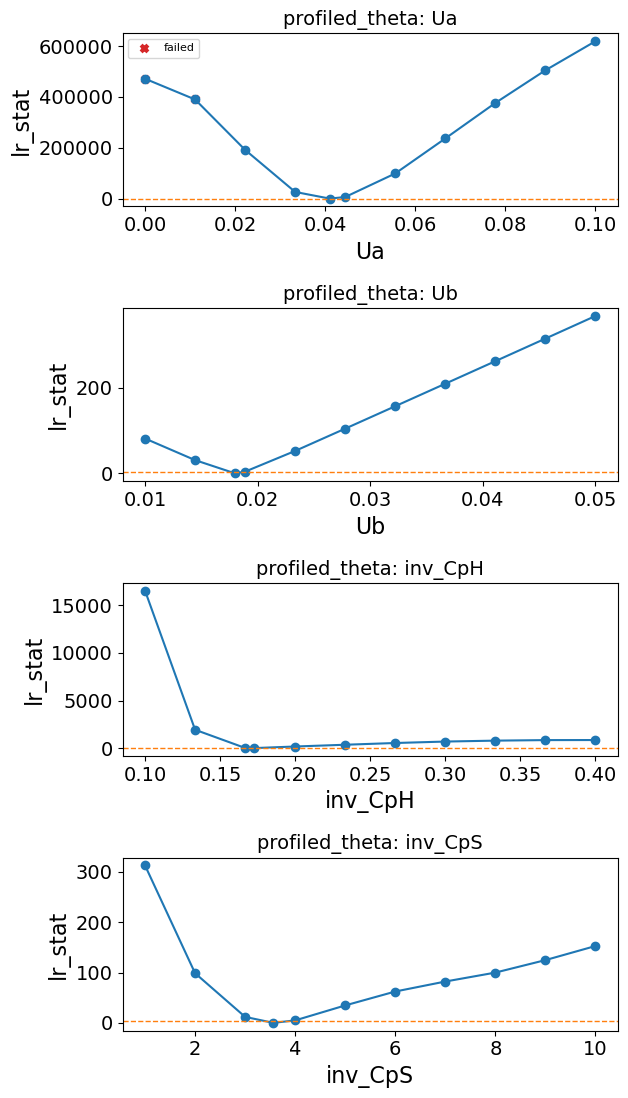

In [27]:
# Do profile likelihood estimation to construct confidence intervals for the parameters. 
# This is a more robust method for constructing confidence intervals, 
# as it does not rely on the assumption of normality in the parameter estimates.

# Compute profile likelihood for both unknown parameters.
# Use a small grid for quick terminal runs.
profile_results_L1_phys = pest_regL1_phys.profile_likelihood(
    profiled_theta=["Ua", "Ub", "inv_CpH", "inv_CpS"],
    n_grid=10,
    solver="ef_ipopt",
    warmstart="neighbor",
    # Demon`strate baseline from multistart integration:
    use_multistart_for_baseline=False,
    # baseline_multistart_kwargs={
    #     "n_restarts": 5,
    #     "multistart_sampling_method": "uniform_random",
    #     "seed": 7,
    # },
)

# Display a compact summary table
profiles = profile_results_L1_phys["profiles"]
print("\nBaseline:")
print(profile_results_L1_phys["baseline"])
print("\nProfile results (first 12 rows):")
print(
    profiles[
        [
            "profiled_theta",
            "theta_value",
            "obj",
            "delta_obj",
            "lr_stat",
            "status",
            "success",
        ]
    ].head(12)
)

# Plot profile curves to file for terminal/non-GUI usage
parmest.graphics.profile_likelihood_plot(
    profile_results_L1_phys, alpha=0.95, 
)


In [28]:
if parmest.graphics.seaborn_available:
    parmest.graphics.pairwise_plot(
        (theta, cov, 100),
        theta_star=theta,
        alpha=0.8,
        distributions=['MVN'],
        title='Theta estimates within 80% confidence region',
    )

LinAlgError: When `allow_singular is False`, the input matrix must be symmetric positive definite.